# Análisis de MSFT

Se realiza un análisis de las acciones de Microsoft en tiempo real por día para ver como se comporta frente al mercado.

Se utiliza la API de **Alpha Vantage** que es un servicio que proporciona datos financieros en tiempo real e históricos.

El notebook se actualiza a las 19:00, hora de Bolivia (UTC-4)

### Cargar librerias

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
from datetime import datetime

from alpha_vantage.timeseries import TimeSeries
import mplfinance as mpf

from statsmodels.graphics.tsaplots import plot_pacf, plot_acf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from skforecast.recursive import ForecasterRecursive
from skforecast.model_selection import backtesting_forecaster, TimeSeriesFold, grid_search_forecaster

sns.set_style("dark")    
sns.set_context("paper") 

In [ ]:
print("hora maquina UTC-1: ", datetime.now())

2025-12-18 09:51:32.802599


### Obtener datos

Se realiza la obtención de datos por API de la página web de Alpha Vantage y luego se renombraron las columnas

In [7]:
api_key = "G1IMZVJ1KGOAPL7Y"

ts = TimeSeries(key=api_key, output_format='pandas')
df, meta_data = ts.get_daily(symbol='MSFT', outputsize='compact' ) 
df = df.rename(columns={
    '1. open':'open', '2. high':'high', '3. low':'low',
    '4. close':'close', '5. volume':'volume'
    })
df = df.sort_index()
df.tail()

,open,high,low,close,volume
date,,,,,
2025-12-11,476.630,486.0300,475.86,483.47,24669180.0
2025-12-12,479.820,482.4500,476.34,478.53,21248102.0
2025-12-15,480.100,480.7205,472.52,474.82,23727694.0
2025-12-16,471.905,477.8900,470.88,476.39,20705560.0
2025-12-17,476.905,480.0000,475.00,476.12,23246350.0


Se gráfico los ultimos 100 días del cierre de las acciones de Microsoft

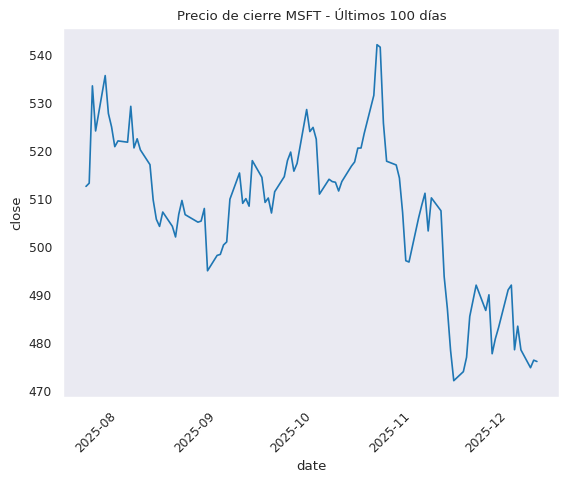

In [8]:
sns.lineplot(x=df.index, y=df['close'])
plt.title("Precio de cierre MSFT - Últimos 100 días")
plt.xticks(rotation=45);

La volatibilidad de los datos es baja, ya que los valores se central alrededor de 0

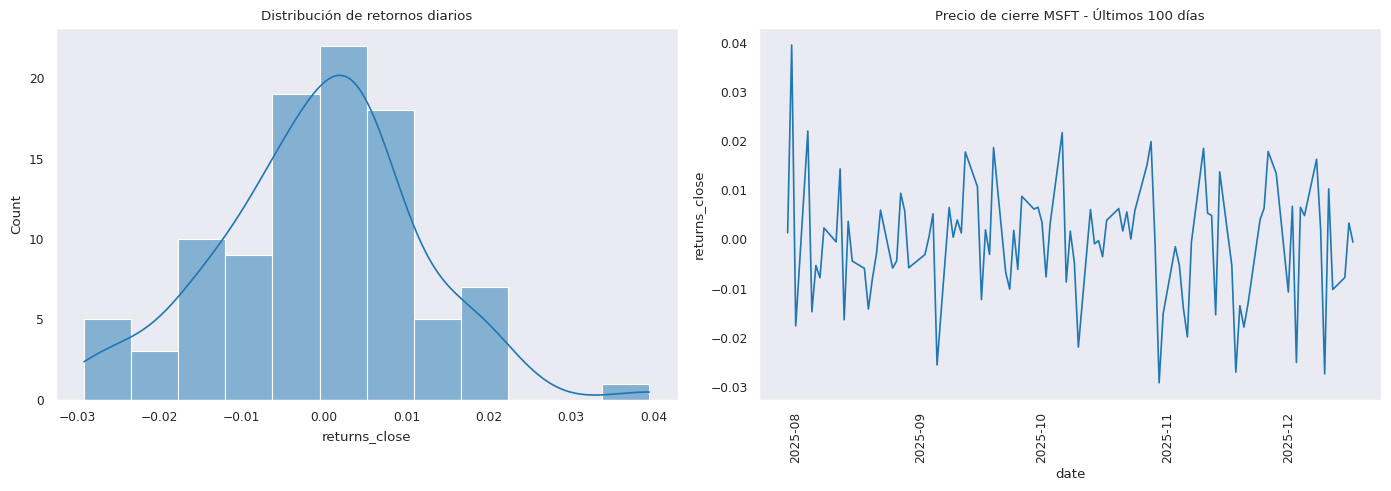

In [9]:
df['returns_close'] = df['close'].pct_change(fill_method=None)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))  
sns.histplot(df['returns_close'].dropna(), kde=True, ax=axes[0])
axes[0].set_title("Distribución de retornos diarios")

sns.lineplot(x=df.index, y=df['returns_close'], ax=axes[1])
axes[1].set_title("Precio de cierre MSFT - Últimos 100 días")
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout();

Gráfico de la estacionalidad agrupado por cada día de la semana

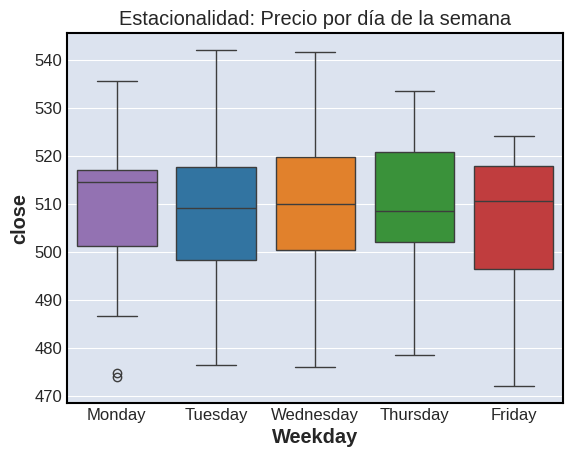

In [23]:
df['Weekday'] = df.index.day_name()

sns.boxplot(x='Weekday', y='close', data=df,
            order=['Monday','Tuesday','Wednesday','Thursday','Friday'],
            hue="Weekday")
plt.title("Estacionalidad: Precio por día de la semana");

Gráfico de la estacionalidad por mes

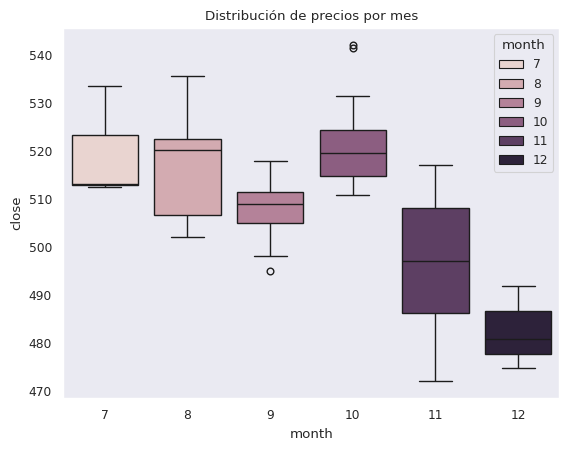

In [11]:
sns.set_style("dark") 
df['month'] = df.index.month

sns.boxplot(x='month', y='close', data=df, hue="month")
plt.title("Distribución de precios por mes");

### Gráficos de Autocorrelación en Close y Returns Close

Gráfico de Autocorrelación y Autocorrelación Parcial de Close, en el cual se observa que la 1ra gráfica existe rezagos significativos, mientras que en la 2da gráfica solo hay 1 rezago significativo.

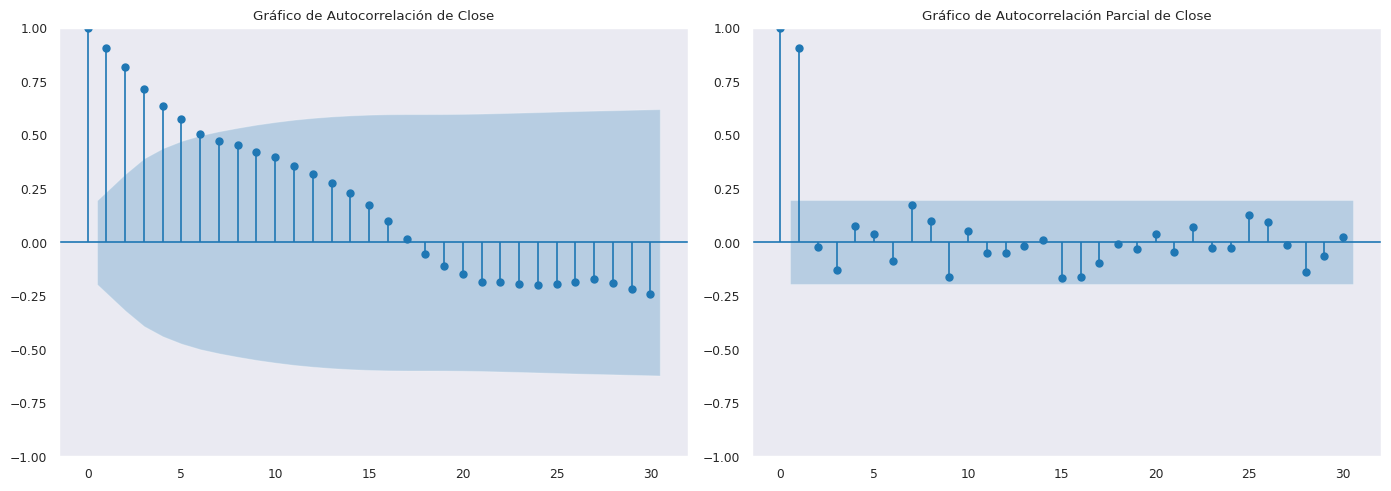

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))  

plot_acf(df.close, lags=30, ax=axes[0], title="Gráfico de Autocorrelación de Close")

plot_pacf(df.close, lags=30, ax=axes[1], title="Gráfico de Autocorrelación Parcial de Close")

plt.tight_layout();

Con respecto a Returns Close no hay rezagos significativos

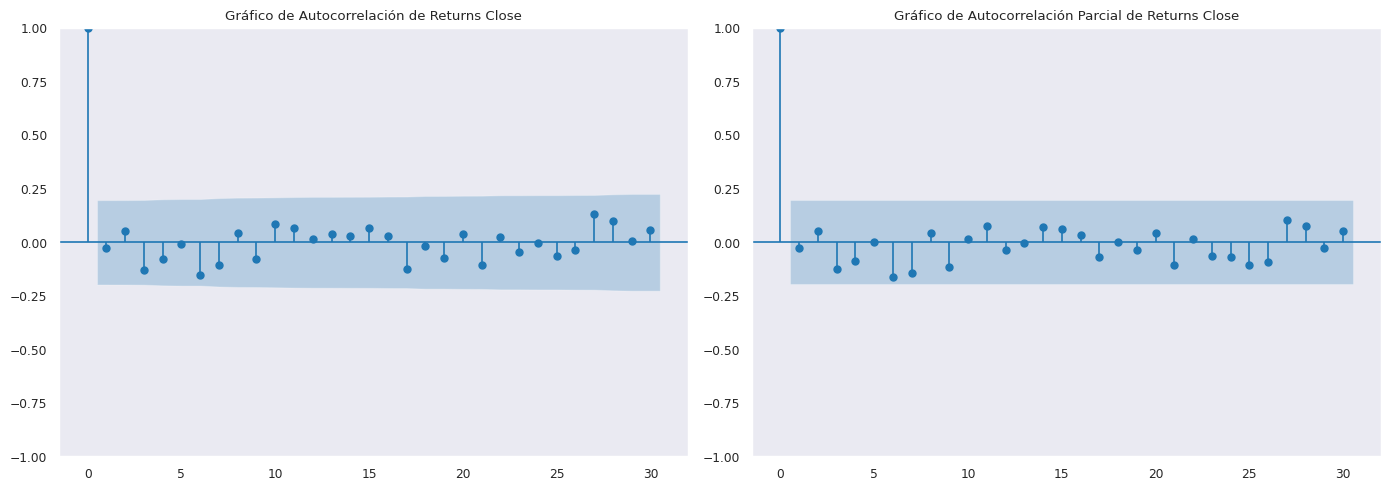

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5)) 

plot_acf(df.returns_close.dropna(), lags=30, ax=axes[0], title="Gráfico de Autocorrelación de Returns Close")

plot_pacf(df.returns_close.dropna(), lags=30, ax=axes[1], title="Gráfico de Autocorrelación Parcial de Returns Close")

plt.tight_layout();

La tendencia y la volativilidad de Close se mantienen constante, con una ligera bajada

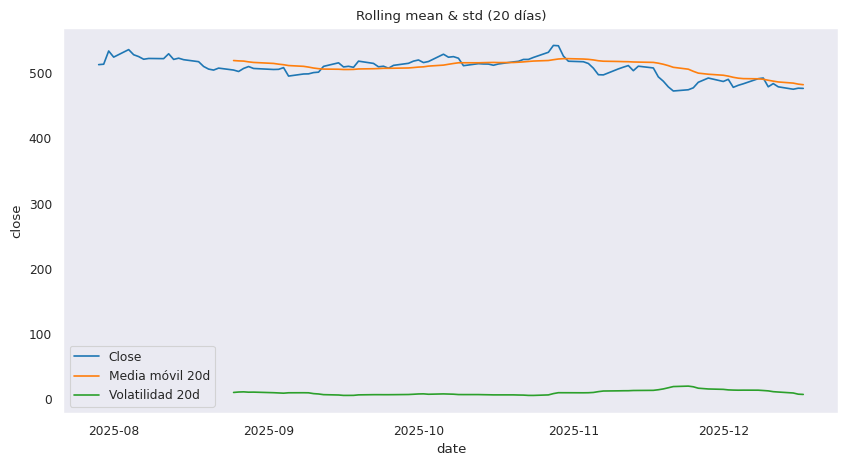

In [14]:
df['rolling_mean'] = df['close'].rolling(window=20).mean()
df['rolling_std'] = df['close'].rolling(window=20).std()

plt.figure(figsize=(10,5))
sns.lineplot(x=df.index, y=df['close'], label='Close')
sns.lineplot(x=df.index, y=df['rolling_mean'], label='Media móvil 20d')
sns.lineplot(x=df.index, y=df['rolling_std'], label='Volatilidad 20d')
plt.title("Rolling mean & std (20 días)")
plt.legend();

El gráfico muestra la evolución del precio de MSFT con velas japonesas con bandas, volumen y una media móvil de 20 días.

Se puede observa que el precio en ciertas epocas tenia una tendencia alcista y en otras hubo una tendencia a la baja

En la parte baja del gráfico no se nota claramente si los movimientos brusco del volumen afecten al precio.

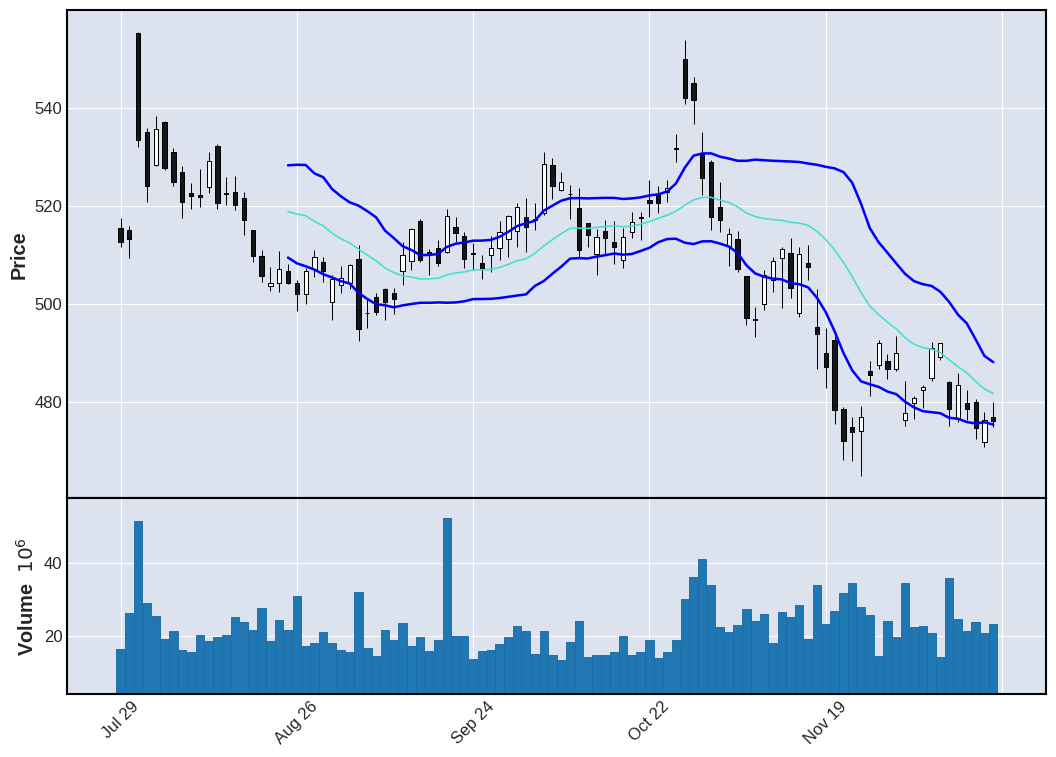

In [15]:
upper_band = df.rolling_mean + df.rolling_std
lower_band = df.rolling_mean - df.rolling_std

# Crear addplots
ap = [
    mpf.make_addplot(upper_band, color='blue'),
    mpf.make_addplot(lower_band, color='blue'),
]

mpf.plot( df, type='candle', volume=True, mav=(20), figscale=1.7, addplot=ap)

Test de estacionariedad (ADF test)
El p-value es < 0.05, la serie es estacionaria

In [16]:
print('p-value:', adfuller(df['returns_close'].dropna())[1])

p-value: 1.1492937796563533e-17


Descomposición estacional utilizando promedios móviles

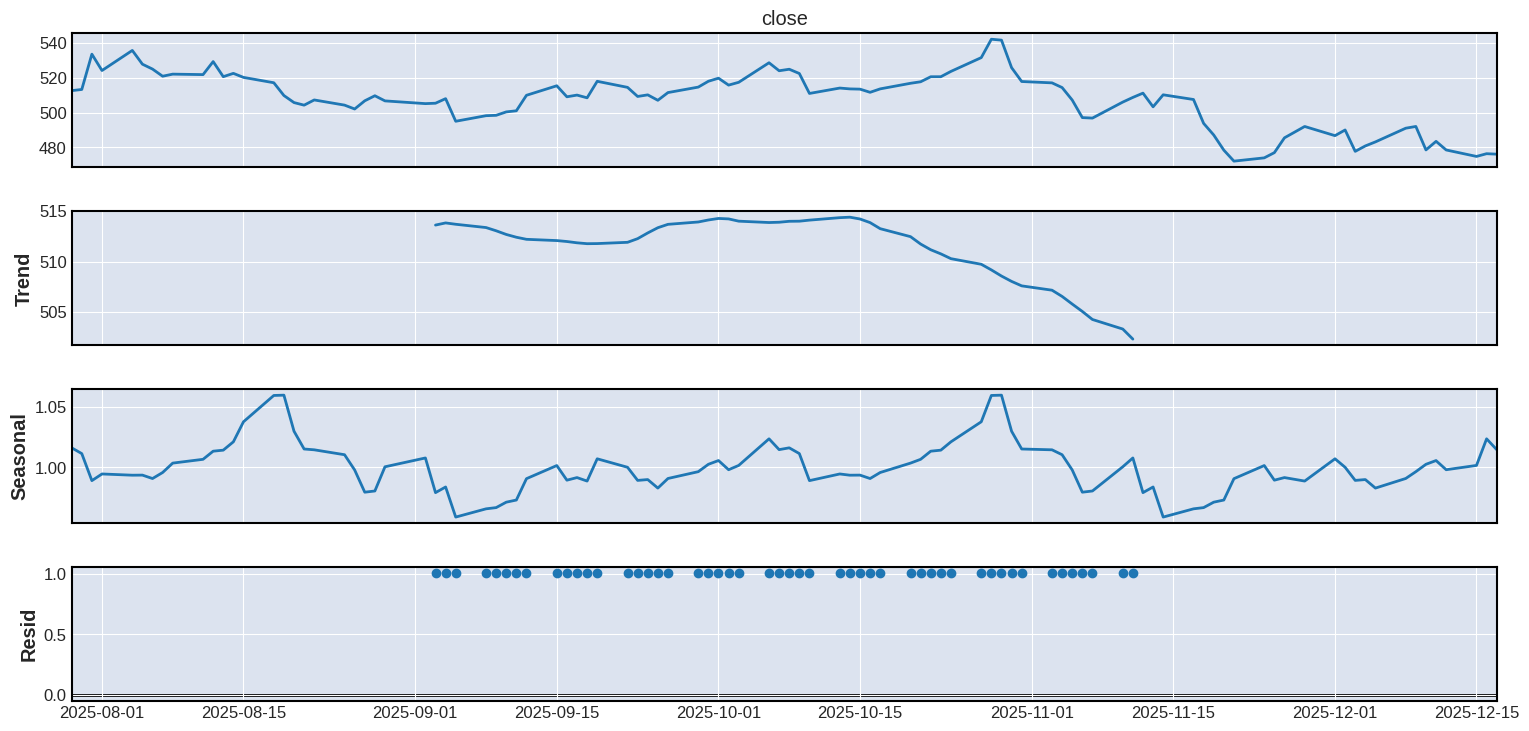

In [26]:
seasonal_decompose(df['close'], model='mul', period=50).plot().set_size_inches(18,8);

### Preprocesamiento

Se crea una serie que contenga los datos de Close, el índice se cambia de formato a una frecuencia de Business Day, y se rellena los dias festivos con valores anteriores 

Cada 7 días el modelo aprender a pronosticar el valor

In [18]:
serie = df['close']

serie.index = pd.to_datetime(serie.index)
serie = serie.asfreq('B')            
serie = serie.ffill()

horizon = 7
initial_train_size = len(serie) - 50 

### Modelado

Se selecciona varios modelos para elegir el modelo con el menor RMSE

In [19]:
modelos = {
    "linreg": LinearRegression(),
    "ridge": Ridge(random_state=42),
    "lasso": Lasso(random_state=42),
    "enet": ElasticNet(random_state=42),
    "rf": RandomForestRegressor(random_state=42, n_jobs=-1),
    "gb": GradientBoostingRegressor(random_state=42)
}

resultados = {}

cv_esquema = TimeSeriesFold(
    initial_train_size = initial_train_size,
    steps = horizon,
    refit = False
)

for name, modelo in modelos.items():
    forecaster = ForecasterRecursive(estimator=modelo, lags=20)
    
    _, preds = backtesting_forecaster(
        forecaster = forecaster,
        y = serie,
        cv = cv_esquema,
        metric = 'mean_squared_error',
        verbose = False,
        show_progress = False
    )
    
    y_real = serie.loc[preds.index]
    
    resultados[name] = {
        "RMSE": root_mean_squared_error(y_real, preds['pred']),
        "MAE": mean_absolute_error(y_real, preds['pred']),
        "R2": r2_score(y_real, preds['pred'])
    }

df_resultados = pd.DataFrame(resultados).transpose().sort_values("RMSE")
print("\n--- Ranking de Modelos (Ordenados por RMSE) ---")
print(df_resultados)


--- Ranking de Modelos (Ordenados por RMSE) ---
             RMSE        MAE        R2
lasso   16.255118  13.172454  0.247065
enet    16.386125  13.150448  0.234880
ridge   16.959332  13.505579  0.180414
linreg  16.970321  13.517292  0.179352
gb      20.005798  16.445986 -0.140483
rf      20.082475  16.040572 -0.149242


Se realizara un optimización de los parametros en el mejor modelo.

In [20]:
param_grid = {
    'ridge': {
        'alpha': [0.01, 0.1, 1.0, 10.0, 50.0], 'fit_intercept': [True, False],
        'solver': ['auto', 'svd', 'cholesky', 'lsqr']
    },

    'lasso': {
        'alpha': [0.0001, 0.001, 0.01, 0.1, 1.0], 'fit_intercept': [True, False],
        'selection': ['cyclic', 'random']
    },

    'enet': {
        'alpha': [0.0001, 0.001, 0.01, 0.1], 'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9],
        'fit_intercept': [True, False], 'selection': ['cyclic', 'random']
    },

    'rf': {
        'n_estimators': [50, 100, 200], 'max_depth': [3, 5, 10, None],
        'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2', None]
    },

    'gb': {
        'n_estimators': [50, 100, 200], 'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [2, 3, 4], 'subsample': [0.6, 0.8, 1.0], 'min_samples_split': [2, 5, 10]
    }
}

top_model_name = df_resultados.index[0]
print(f"\n--- Optimizando {top_model_name} ---")

forecaster_best = ForecasterRecursive(
    estimator = modelos[top_model_name], 
    lags = 20
    )

resultado_grid = grid_search_forecaster(
    forecaster = forecaster_best,
    y = serie,
    param_grid = param_grid[top_model_name],
    cv = cv_esquema,
    metric = 'mean_squared_error',
    return_best = True,
    verbose = False,
    show_progress = False, 
)
print(f"RMSE con Grid: ", np.sqrt(resultado_grid["mean_squared_error"][0]))


--- Optimizando lasso ---
`Forecaster` refitted using the best-found lags and parameters, and the whole data set: 
  Lags: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20] 
  Parameters: {'alpha': 1.0, 'fit_intercept': True, 'selection': 'cyclic'}
  Backtesting metric: 264.22887724798346
RMSE con Grid:  16.255118493815523


Entrenamiento final con todo el conjuto de datos y pronosticar los próximos 7 días

In [27]:
pio.renderers.default = "notebook_connected"

forecaster_best.fit(y=serie)
predicciones = forecaster_best.predict(steps=horizon)

historico = go.Scatter( x=serie.iloc[-30:].index, y=serie.iloc[-30:],
    mode='lines+markers', name="Histórico (Últimos 30 días)"
)

pred = go.Scatter( x=predicciones.index, y=predicciones,
    mode='lines+markers', name="Predicción a Futuro",
    line=dict(color='red'), marker=dict(size=8)
)

fig = go.Figure(data=[historico, pred])

fig.update_layout(
    title=f"MSFT: Predicción a 7 días con modelo {top_model_name.upper()}",
    xaxis_title="Fecha", yaxis_title="Precio de Cierre",
    template="plotly", legend=dict(x=1, y=1),
)

fig.show()

In [28]:
print(f"Las predicciones para los próximos 7 días son\n {predicciones.round(3)}")

Las predicciones para los próximos 7 días son
 2025-12-18    481.486
2025-12-19    484.814
2025-12-22    487.940
2025-12-23    489.408
2025-12-24    490.040
2025-12-25    490.559
2025-12-26    490.070
Freq: B, Name: pred, dtype: float64
